![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Tokenización de textos  

En este taller podrán poner en práctica sus conocimientos sobre preprocesamiento de texto (tokenización). El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos detección de toxicidad en comentarios

En este taller se usará el conjunto de datos de detección de toxicidad en comentarios de la base de datos de Kaggle. Cada observación es un comentario que tiene como variable objetivo (target) la probabilidad de ser un comentario tóxico. El objetivo es predecir la toxicidad de cada comentario. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification/data).

In [1]:
# SUGERIDO: Descomenta la siguiente linea de código si requieres instalar las libreías básicas utilizadas en este notebook
# Si requieres incluir más librerías puedes agregarlas al archivo Semana 4\requirements.txt
# !pip install -r requirements.txt

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from IPython.display import Markdown, display
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns
import pandas as pd
import numpy as np
import scipy as sp
%matplotlib inline

In [4]:
# Carga de datos de archivos .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/Toxicity.zip')
df = df[['id','comment_text', 'target']]
df.head()

,id,comment_text,target
0,6101457,What are you talking about? What group do Pete...,0.0
1,5342103,"NO!, Let him, we need a Conservative government.",0.0
2,743361,"Perhaps he took the ""power out of the Cardinal...",0.2
3,551008,"As always, yours is dripping with sarcasm, whi...",0.0
4,865998,The dirty little secret is that the price rang...,0.3


In [5]:
df.shape

(541462, 3)

<Axes: >

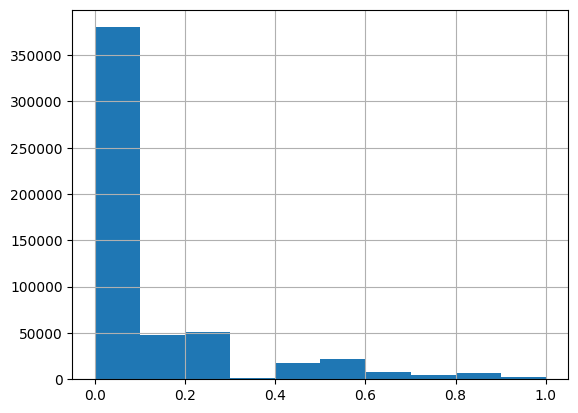

In [6]:
# Impresión histograma de variable de interés (y)
df.target.hist()

In [7]:
# Separación de variable de interés (y)
y = df.target
y.describe()

count    541462.000000
mean          0.102991
std           0.196979
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: target, dtype: float64

In [8]:
# Separación de variables predictoras (X), solo se considera el texto de la noticia
X = df.comment_text

In [9]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Punto 1 - Tokenización con CountVectorizer

En la celda 1 creen y entrenen el modelo de regresión de su preferencia, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

Se puede ver que los datos estan imbalanceados, dado que la moyoría de las observaciones se encunetran en probabilidades entre 0 y 0.1, mientras que las demás observaciones
                 que tienen probabilidades más altas de ser un comentario tóxico, tienen una representación menor, por ello se observa la distribución de valores de manera más detallada para poder
                 definir una estrategia que mejore la calidad de los datos de entrenamiento y por ende, la calibración del modelo de regresión.

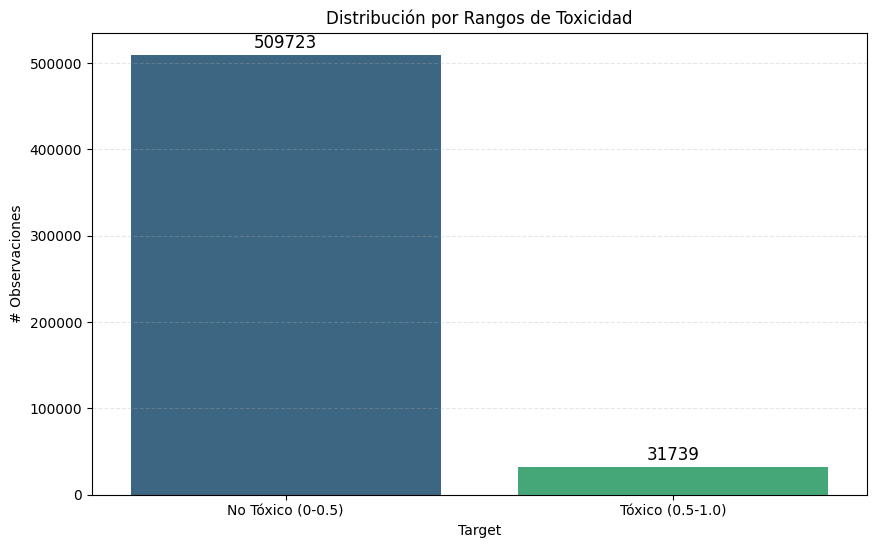

Mediante la gráfica anterior, se puede corrborar que los datos de Train se encuentran desbalanceados, teniendo apenas un 5% de observaciones que superan la probabilidad de 0.5, 
                 por lo qu si se entrenara un modelo con estos datos, el modelo podría aprender a predecir que casi todos los comentarios no son toxicos, dado que se entrenó con datos en donde
                 mas de un 90% son casos en donde no hay toxicidad.

                 
 Por lo cual, se hará un Under Sampling mediante 'RandomUnderSampler' para que tengamos la misma cantidad de observaciones para cada rango definido.

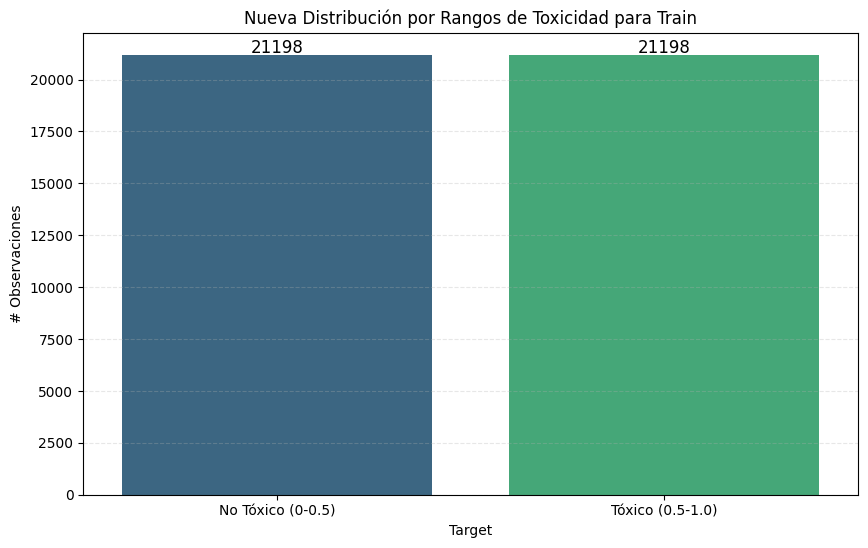

Después de hacer un undersample, se puede ver que la cantidad de observaciones que tienen una probabilidad de ser un comentario tóxico (0 - 0.5), es igual a la cantidad de
                 observaciones para comentarios tóxicos (0.5 - 1).

In [10]:
# Celda 1
display(Markdown(f"""Se puede ver que los datos estan imbalanceados, dado que la moyoría de las observaciones se encunetran en probabilidades entre 0 y 0.1, mientras que las demás observaciones
                 que tienen probabilidades más altas de ser un comentario tóxico, tienen una representación menor, por ello se observa la distribución de valores de manera más detallada para poder
                 definir una estrategia que mejore la calidad de los datos de entrenamiento y por ende, la calibración del modelo de regresión."""))

#Se definen grupos de probabilidd para poder observar de manera aislada la distribución de las observaciones
bins = [0, 0.5, 1.0] 
labels = ['No Tóxico (0-0.5)', 'Tóxico (0.5-1.0)']
df['rango_toxicidad'] = pd.cut(df['target'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rango_toxicidad', palette='viridis')
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

plt.title('Distribución por Rangos de Toxicidad')
plt.xlabel('Target')
plt.ylabel('# Observaciones')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

display(Markdown(f"""Mediante la gráfica anterior, se puede corrborar que los datos de Train se encuentran desbalanceados, teniendo apenas un 5% de observaciones que superan la probabilidad de 0.5, 
                 por lo qu si se entrenara un modelo con estos datos, el modelo podría aprender a predecir que casi todos los comentarios no son toxicos, dado que se entrenó con datos en donde
                 mas de un 90% son casos en donde no hay toxicidad.
                 
                 \n Por lo cual, se hará un Under Sampling mediante 'RandomUnderSampler' para que tengamos la misma cantidad de observaciones para cada rango definido."""))

#Under Sampling
us = RandomUnderSampler(sampling_strategy='not minority', random_state=42) #Se bajan todas las categorias para igualar la cantidad de valores de la más baja
y_train_aux = pd.cut(y_train, bins=bins, labels=labels, include_lowest=True)
X_train_res, y_train_aux_res = us.fit_resample(X_train.values.reshape(-1, 1), y_train_aux)
indices = us.sample_indices_ #Indices de las observaciones aleatorias que se van a mantener
X_train_final = X_train.iloc[indices]
y_train_final = y_train.iloc[indices]

dist_final = pd.cut(y_train_final, bins=bins, labels=labels, include_lowest=True)
plt.figure(figsize=(10, 6))
sns.countplot(x=dist_final, palette='viridis')
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext = (0, 5), textcoords = 'offset points', fontsize=12)

plt.title('Nueva Distribución por Rangos de Toxicidad para Train')
plt.xlabel('Target')
plt.ylabel('# Observaciones')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

display(Markdown(f"""Después de hacer un undersample, se puede ver que la cantidad de observaciones que tienen una probabilidad de ser un comentario tóxico (0 - 0.5), es igual a la cantidad de
                 observaciones para comentarios tóxicos (0.5 - 1)."""))

Se hace la calibración de un modelo XGBoost usando RandomizedSearchCV con early stopping, por lo cual se hace la division del set de entrenamiento en Train y Validation,
                 pero antes de aplicar esta división, se hace la vectorización de la informatción para que el modelo de regresión la pueda procesar de manera adecuada.

Se obtiene que el modelo resultante analizado en el set de datos de test cuenta con un MSE de 0.0518

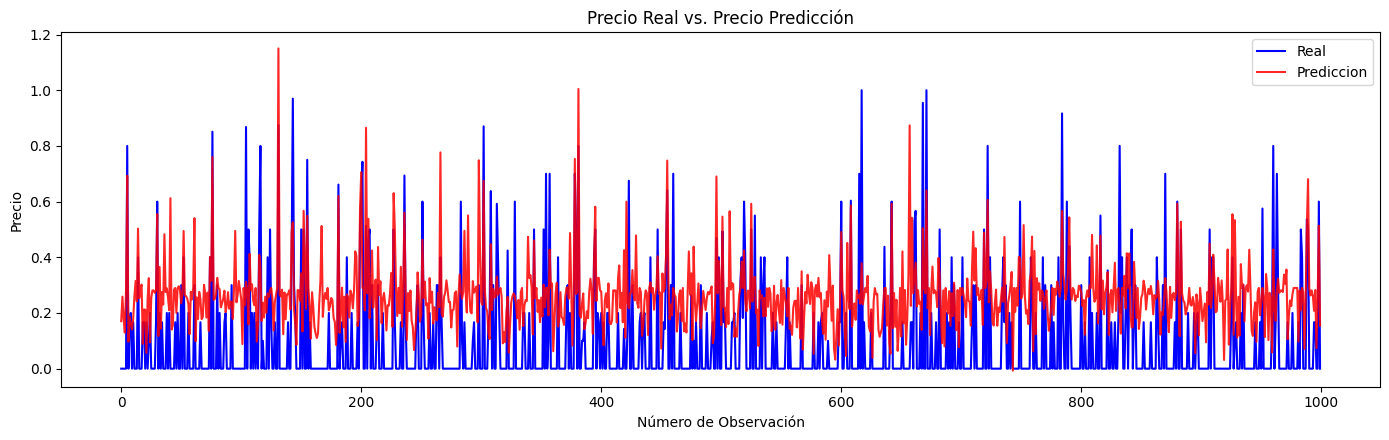

In [ ]:
display(Markdown(f"""Se hace uso de un modelo de regresion con XGBoost y una vectorización con CountVectorizer. """))

#Se aplica un procesamiento a los comentarios mediante 'CountVectorizer'
vect = CountVectorizer(lowercase=False) #Todo a minuscula
X_Train_Vect = vect.fit_transform(X_train_final)
X_test_vect = vect.transform(X_test)

clf_xgb = XGBRegressor(random_state=10)
clf_xgb.fit(X_Train_Vect, y_train_final)
y_pred_test_xgb = clf_xgb.predict(X_test_vect)
mse_test_xgb = metrics.mean_squared_error(y_test, y_pred_test_xgb)
display(Markdown(f"""Se obtiene que el modelo resultante analizado en el set de datos de test cuenta con un MSE de {mse_test_xgb:.4f}"""))

#Gráfica
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(y_pred_test_xgb[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

## Punto 2 - Tokenización con CountVectorizer y trigramas

En la celda 2 creen y entrenen el mismo modelo de regresión del punto anterior (es decir si usaron un RandomForestRegresor usen nuevamente ese regresor), para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer **considerando trigramas** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

Se hace uso de un modelo de regresion con XGBoost y una vectorización0con CountVectorizer. 

Se obtiene que el modelo resultante analizado en el set de datos de test cuenta con un MSE de 0.0521

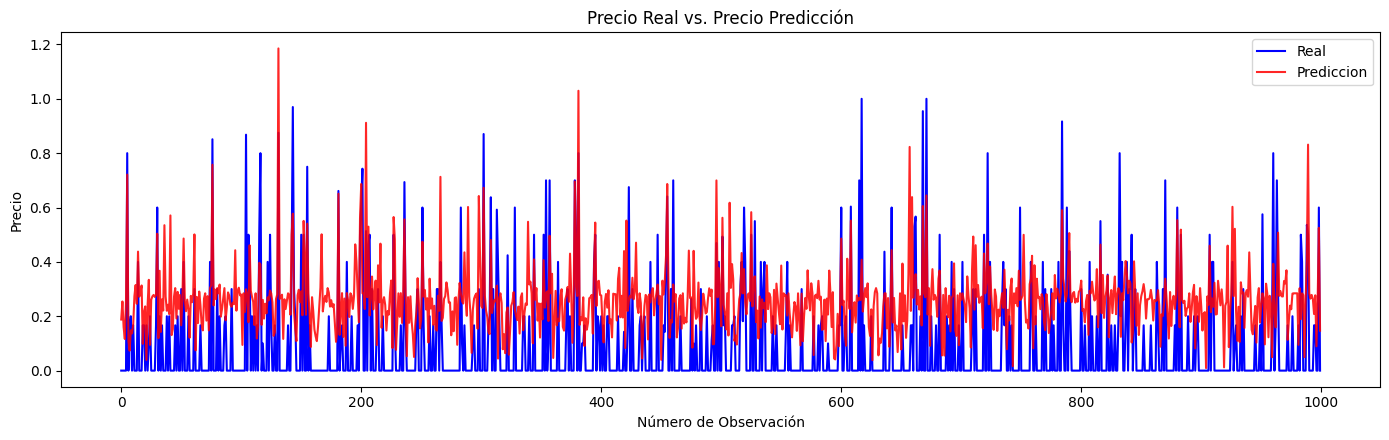

In [ ]:
display(Markdown(f"""Se hace uso de un modelo de regresion con XGBoost y una vectorización con CountVectorizer. """))

#Se aplica un procesamiento a los comentarios mediante 'CountVectorizer'
vect_Tri = CountVectorizer(lowercase=False, ngram_range=(1,3)) #Todo a minuscula
X_Train_Vect_Tri = vect_Tri.fit_transform(X_train_final)
X_test_vect_Tri = vect_Tri.transform(X_test)

clf_xgb_Tri = XGBRegressor(random_state=10)
clf_xgb_Tri.fit(X_Train_Vect_Tri, y_train_final)
y_pred_test_xgb_Tri = clf_xgb_Tri.predict(X_test_vect_Tri)
mse_test_xgb_Tri = metrics.mean_squared_error(y_test, y_pred_test_xgb_Tri)
display(Markdown(f"""Se obtiene que el modelo resultante analizado en el set de datos de test cuenta con un MSE de {mse_test_xgb_Tri:.4f}"""))

#Gráfica
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(y_pred_test_xgb_Tri[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

## Punto 3 - TfidfVectorizer

Investigen sobre la función TfidfVectorizer. En la celda de texto 3, expliquen en qué consiste esta técnica de tokenización (describanla y expliquen su funcionamiento) y cúales son las ventajas o deventajas de su uso al compararlo con la función CountVectorizer.

In [ ]:
#Celda 3


## Punto 4 - Tokenización con TfidfVectorizer

En la celda 4 creen y entrenen el mismo modelo de regresión del primer punto, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Procesen los comentarios con la función **TfidfVectorizer** y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [ ]:
# Celda 4


## Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos y comenten cómo el preprocesamiento de texto afecta el desempeño.

In [ ]:
# Celda 5 Código para graficos y tablas comparativas


In [ ]:
### Punto 5.1 - Comparación y análisis de resultados
